# V3 Orienteering Problem: Full Parameter Optimisation
## `05_v3_orienteering.ipynb`

**V3-OP** extends V2-OP by adding **observation pattern geometry** (leg length $L$, number of
legs $m$, spacing $s$) as optimization variables. This is the most general formulation.
This notebook runs V1, V2, and V3 on the same scenario for a direct, fair comparison.

---

## What Changes from V2 → V3?

| Cell type | V1 fixed | V2 adds | V3 adds |
|-----------|----------|---------|---------|
| Circular  | all fixed | free $\theta$ | free $\theta$ + free $L$ |
| Elliptical| all fixed | free $\theta$ | free $\theta$ + free $m$, $s$ |

### Trade-offs in V3

**Circular cells — free leg half-length $L$:**
- Score is always $w_i$ once visited (L does not affect score, only geometry)
- Larger $L$ → entry/exit points further from center → may change transit cost to neighbors
- Larger $L$ → longer internal flight ($d^\text{int} \propto L$) → more budget consumed
- *V3 strategy*: prefer smaller $L$ to save budget, unless a larger $L$ substantially reduces transit

**Elliptical cells — free leg count $m$ and spacing $s$:**
$$\text{score} \propto \frac{\min\bigl((m-1)s,\, W_\perp(\theta)\bigr)}{W_\perp(\theta)} \quad \text{(saturates at full width coverage)}$$
- Fewer legs → shorter internal flight, but may miss width coverage → score penalty
- *V3 strategy*: find smallest $m$ such that $(m-1)s \approx W_\perp(\theta)$ — cover the ellipse
  width exactly with fewest legs, minimising internal distance while maintaining score

**Key insight:** sparser patterns sacrifice a tiny amount of score per cell but free up budget
to visit **one additional high-value cell** — the net gain is positive.

### Discretisation (to keep the search tractable)

| Variable | Cell type | Values |
|---|---|---|
| $L$ | Circular | $r + \{15, 35, 55, 75\}$ km (4 levels above minimum reach) |
| $m$ | Elliptical | $\{2, 3, 4, 5\}$ (4 values) |
| $s$ | Elliptical | $\{10.0, 15.0, 20.0\}$ km (3 values) |

Combined with T = 12 θ values, the per-cell configuration space is:
- Circular: $12 \times 4 = 48$ configurations
- Elliptical: $12 \times 12 = 144$ configurations (~48× larger search space than V1)

---

## Mathematical Model (V3 — No Exact Formulation)

V3 does not admit a tractable MILP at scale. The joint problem
— select supercells + sequence + assign $(\theta, L, m, s)$ per cell —
is **NP-hard** and the search space per cell is ~48× larger than V1.

Instead, V3 uses ALNS with full configuration enumeration.

**Effective arc cost in V3** (depends on both endpoints' full configurations):
$$c'_{(i,\,\text{cfg}_i),\,(j,\,\text{cfg}_j)} = c_{ij}(\text{cfg}_i, \text{cfg}_j) + d^\text{int}_j(\text{cfg}_j)$$

where $\text{cfg} = (\theta, L)$ for circular or $\text{cfg} = (\theta, m, s)$ for elliptical cells.

---

## ALNS Extensions for V3

V3 re-uses the full V2 ALNS framework and extends the θ-aware components to cover all parameters:

```
Destroy operators:  same as V1/V2 (rand_1, rand_2, worst)

Repair operators:
  → best_cfg_for_insert:  when inserting node k, enumerate ALL (θ, L) or (θ, m, s)
                          configurations; choose the (config, position) with best
                          score / insertion-cost ratio

Post-repair local search (V3 extension of V2 theta_local_search):
  → param_ls:  for every node in the current tour, try ALL configurations;
               accept any that improve score without violating the budget.
               Applied after every repair step.
```

**Computational cost:** V3 `param_ls` evaluates up to 144 configs × N nodes per iteration,
vs 12 configs in V2. Runtime increases substantially (~70× vs V2 on this benchmark).

---

## Algorithms and Optimality

### V3 ALNS — **local optimum, heuristic only, no global guarantee**
- No exact algorithm is implemented for V3 (MILP would require $\sim N \times 144$ virtual nodes
  plus subtour and config constraints — computationally prohibitive for N = 20)
- `param_ls` achieves a local optimum with respect to single-node configuration changes
- Joint optimality over all (selection + order + config) is **not guaranteed**
- The problem is NP-hard; even the MILP-exact V1/V2 results are exact only within their
  respective discretized parameter spaces

### Why V3 adds substantial value despite being heuristic-only:
1. **Frees budget**: reducing L/m/s cuts internal flight distances dramatically, freeing budget for more cells
2. **Large gain**: V3 visits 17/20 cells vs V1's 11/20 within the same budget
3. **Foundation**: same ALNS structure is ready for Learning-Augmented extensions (LA-ALNS)

---

## Final Comparison: V1 → V2 → V3 (N = 20, budget = 8,262 km, max score = 32.260)

| Version | Decision variables | Optimality | Supercells visited | Score | % of max | Distance | Time |
|---|---|---|---|---|---|---|---|
| V1 ALNS | visit + order | Local opt. (heuristic) | 11 | 18.579 | 57.6% | 7,709 km | 28 s |
| V2 ALNS | + scan direction θ | Local opt. (heuristic) | 13 | 20.007 | 62.0% | 8,227 km | 500 s |
| V3 ALNS | + leg params L/m/s | Local opt. (heuristic) | **17** | **26.882** | **83.3%** | 8,257 km | 2,033 s |

- **V2 over V1**: +1.428 score (+7.7%), 2 extra cells
- **V3 over V2**: +6.875 score (+34.4%), 4 extra cells — the dominant gain
- **V3 over V1**: +8.303 score (+44.7%), 6 extra cells


In [1]:
import os, time, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse
from dataclasses import dataclass
from typing import List, Tuple
import pulp

warnings.filterwarnings('ignore')
os.makedirs('figures', exist_ok=True)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

def uvec(a): return np.array([np.cos(a), np.sin(a)])

# ── Data structures (same as 03 / 04) ────────────────────────
@dataclass
class CircularSupercell:
    center: np.ndarray
    radius: float; L: float; theta: float   # L and theta are defaults; overridden in V3
    weight: float = 1.0; name: str = "TPV"

@dataclass
class EllipticalSupercell:
    center: np.ndarray
    a: float; b: float; phi: float; m: int; s: float; theta: float  # m,s,theta are defaults
    weight: float = 1.0; name: str = "Jet"
    def _ellipse_intersect(self, lc, theta):
        cp, sp = np.cos(self.phi), np.sin(self.phi)
        d = uvec(theta)
        dl = np.array([d[0]*cp+d[1]*sp, -d[0]*sp+d[1]*cp])
        lc_ = lc - self.center
        ll = np.array([lc_[0]*cp+lc_[1]*sp, -lc_[0]*sp+lc_[1]*cp])
        A = (dl[0]/self.a)**2 + (dl[1]/self.b)**2
        B = 2*(ll[0]*dl[0]/self.a**2 + ll[1]*dl[1]/self.b**2)
        C_ = (ll[0]/self.a)**2 + (ll[1]/self.b)**2 - 1
        disc = B**2 - 4*A*C_
        if disc < 0: return None
        t1, t2 = (-B-np.sqrt(disc))/(2*A), (-B+np.sqrt(disc))/(2*A)
        return lc + t1*d, lc + t2*d

# ── Generate scenario (same seed as 03/04) ────────────────────
N    = 20
BASE = np.array([0.0, 350.0])
BETA = 0.6   # weight of WidthCoverage vs DirAlignment in elliptical score

def generate_scenario(N, frac_circ=0.4, seed=7):
    rng = np.random.default_rng(seed)
    n_c = int(N*frac_circ); cells = []
    xs = rng.uniform(100,900,N); ys = rng.uniform(50,650,N)
    for i in range(n_c):
        r = rng.uniform(40,80); L = rng.uniform(max(90,r+20),140)
        th = rng.uniform(0,np.pi); w = rng.uniform(0.8,2.0)
        cells.append(CircularSupercell(np.array([xs[i],ys[i]]),r,L,th,round(w,2),f"T{i+1}"))
    for i in range(N-n_c):
        a = rng.uniform(60,110); b = rng.uniform(25,45); phi = rng.uniform(0,np.pi)
        m = int(rng.integers(3,7)); s = rng.uniform(12,22); w = rng.uniform(1.0,2.5)
        cells.append(EllipticalSupercell(
            np.array([xs[n_c+i],ys[n_c+i]]),a,b,phi,m,s,phi,round(w,2),f"J{i+1}"))
    return cells

scenario = generate_scenario(N, seed=7)
n_circ = sum(isinstance(c, CircularSupercell)    for c in scenario)
n_ell  = sum(isinstance(c, EllipticalSupercell) for c in scenario)

# ── Theta discretisation (same as V2) ────────────────────────
T         = 12
THETA_SET = np.radians(np.arange(0, 180, 15))     # 0, 15, ..., 165 deg

# ── V3 additional parameter grids ────────────────────────────
# Circular L: 4 steps above the per-cell minimum (radius + 15 km baseline + 20-km increments)
L_OFFSETS = np.array([15, 35, 55, 75], dtype=float)  # km above radius; 4 levels

# Elliptical: m in {2,3,4,5}, s in {10,15,20} km
M_VALS = [2, 3, 4, 5]
S_VALS = [10.0, 15.0, 20.0]

print(f"Scenario  : N={N}  ({n_circ} circular + {n_ell} elliptical)")
print(f"Theta grid: T={T}  ({np.degrees(THETA_SET[0]):.0f}..{np.degrees(THETA_SET[-1]):.0f} deg)")
print(f"L offsets : {list(L_OFFSETS)} km above radius  ({len(L_OFFSETS)} levels per circular cell)")
print(f"m values  : {M_VALS}")
print(f"s values  : {S_VALS} km")
print(f"Max configs per circular cell : T x |L| = {T * len(L_OFFSETS)}")
print(f"Max configs per elliptical cell: T x m x s = {T * len(M_VALS) * len(S_VALS)}")


Scenario  : N=20  (8 circular + 12 elliptical)
Theta grid: T=12  (0..165 deg)
L offsets : [np.float64(15.0), np.float64(35.0), np.float64(55.0), np.float64(75.0)] km above radius  (4 levels per circular cell)
m values  : [2, 3, 4, 5]
s values  : [10.0, 15.0, 20.0] km
Max configs per circular cell : T x |L| = 48
Max configs per elliptical cell: T x m x s = 144


---
## 1. V3 Geometry: Per-Configuration Computation

For every *(cell, theta, L/m/s)* combination we compute:
- **`score`** — effective weighted scientific score
- **`intd`**  — total internal flight distance
- **`cands`** — candidate entry/exit points

Unlike V2 (where a 4D array could be precomputed), V3 parameters vary continuously,
so we compute these quantities **on-the-fly** during ALNS.


In [2]:
# ── V3 geometry: compute (cands, intd, score) for any (cell, config) ──

def circ_config(cell, theta, L):
    # Config for a circular cell at scan direction theta with leg half-length L.
    # Returns (candidates, internal_distance, score).
    # Score is always cell.weight (theta and L do not affect it).
    q = cell.center
    cands = [q + L*uvec(theta),        q - L*uvec(theta),
             q + L*uvec(theta+np.pi/2), q - L*uvec(theta+np.pi/2)]
    intd  = (4.0 + np.sqrt(2.0)) * L
    score = cell.weight
    return cands, intd, score

def ell_config(cell, theta, m, s):
    # Config for an elliptical cell at direction theta with m legs spaced s km.
    # Returns (candidates, internal_distance, score).
    n_vec = uvec(theta + np.pi/2)
    legs  = []
    for i in range(m):
        lc = cell.center + s*(i-(m-1)/2.0)*n_vec
        r  = cell._ellipse_intersect(lc, theta)
        if r: legs.append(r)
    if not legs:
        # Fallback: single leg through centre (degenerate configuration)
        return [cell.center.copy()], 0.0, 0.0

    # Boustrophedon waypoint sequence
    wpts = []
    for i,(ps,pe) in enumerate(legs):
        wpts.extend([ps.copy(),pe.copy()] if i%2==0 else [pe.copy(),ps.copy()])

    cands = [wpts[0], wpts[-1]]
    intd  = sum(np.linalg.norm(wpts[k+1]-wpts[k]) for k in range(len(wpts)-1))

    # Score: WidthCoverage * DirAlignment
    delta   = theta - cell.phi
    W_perp  = 2*np.sqrt(cell.a**2*np.sin(delta)**2 + cell.b**2*np.cos(delta)**2)
    wid_cov = min((m-1)*s, W_perp) / (W_perp + 1e-9)
    L_ctr   = 2*np.sqrt(cell.a**2*np.cos(delta)**2 + cell.b**2*np.sin(delta)**2)
    dir_aln = L_ctr / (2*cell.a)
    score   = cell.weight * (BETA*wid_cov + (1-BETA)*dir_aln)
    return cands, intd, score


def get_config(cell, theta, extra):
    # Unified dispatcher.
    # extra = L for circular;  extra = (m, s) for elliptical.
    if isinstance(cell, CircularSupercell):
        return circ_config(cell, theta, extra)
    else:
        m, s = extra
        return ell_config(cell, theta, m, s)

def transit(cands_i, cands_j):
    # Minimum distance between two candidate-point sets.
    return min(np.linalg.norm(a-b) for a in cands_i for b in cands_j)

# ── V2-compatible default configs (to run V2 baseline inside this notebook) ──
# Default: best scientific theta, given L/m/s from the scenario definition
V2_DEFAULT = {}
for i in range(1, N+1):
    cell = scenario[i-1]
    if isinstance(cell, CircularSupercell):
        # theta closest to 0 (arbitrary for circular); use given L
        V2_DEFAULT[i] = (0, cell.L)         # (theta_idx, L)
    else:
        # theta closest to phi; use given m, s
        k = int(np.argmin([abs(np.sin(THETA_SET[k]-cell.phi)) for k in range(T)]))
        V2_DEFAULT[i] = (k, (cell.m, cell.s))  # (theta_idx, (m, s))

print("V3 geometry helpers defined.")
print()
# Quick sanity: check a circular and an elliptical cell
cell_c = scenario[0]   # first circular
cell_e = next(c for c in scenario if isinstance(c, EllipticalSupercell))
cands, intd, sc = circ_config(cell_c, np.radians(45), cell_c.L)
print(f"Circular {cell_c.name}:  intd={intd:.1f} km  score={sc:.3f}  n_cands={len(cands)}")
cands, intd, sc = ell_config(cell_e, cell_e.phi, cell_e.m, cell_e.s)
print(f"Elliptic {cell_e.name}: intd={intd:.1f} km  score={sc:.3f}  n_cands={len(cands)}")


V3 geometry helpers defined.

Circular T1:  intd=725.6 km  score=1.820  n_cands=4
Elliptic J1: intd=740.8 km  score=2.360  n_cands=2


In [3]:
# ══════════════════════════════════════════════════════════════
# V3 solution representation
# ── tour   : list [0, c1, c2, ..., ck, 0]   (0 = base)
# ── configs: dict { node_i : (theta_k_idx, extra) }
#             where extra = L (circular) or (m, s) (elliptical)
# ══════════════════════════════════════════════════════════════

BASE_CANDS = [BASE.copy()]   # base airport has a single candidate point

def node_cands(node, configs):
    # Return candidate entry/exit points for a node given its current config.
    if node == 0:
        return BASE_CANDS
    cell = scenario[node-1]
    k, extra = configs[node]
    cands, _, _ = get_config(cell, THETA_SET[k], extra)
    return cands

def v3_dist(tour, configs):
    # Total flight distance: sum of transit segments + internal pattern distances.
    total = 0.0
    for s in range(len(tour)-1):
        i, j = tour[s], tour[s+1]
        total += transit(node_cands(i, configs), node_cands(j, configs))
    for node in tour[1:-1]:
        k, extra = configs[node]
        _, intd, _ = get_config(scenario[node-1], THETA_SET[k], extra)
        total += intd
    return total

def v3_score(tour, configs):
    # Total scientific score collected.
    total = 0.0
    for node in tour[1:-1]:
        k, extra = configs[node]
        _, _, sc = get_config(scenario[node-1], THETA_SET[k], extra)
        total += sc
    return total

def ins_delta_v3(tour, configs, node, k, extra, pos):
    # Extra distance of inserting 'node' (at theta k, with params extra) at position pos.
    # = transit(prev->node) + intd(node) + transit(node->nxt) - transit(prev->nxt)
    prev, nxt = tour[pos-1], tour[pos]
    cands_p = node_cands(prev, configs)
    cands_n = node_cands(nxt,  configs)
    cell    = scenario[node-1]
    cands_node, intd, _ = get_config(cell, THETA_SET[k], extra)
    return (transit(cands_p, cands_node) + intd
            + transit(cands_node, cands_n) - transit(cands_p, cands_n))

def rem_delta_v3(tour, configs, node):
    # Distance saved by removing 'node' from tour.
    pos = tour.index(node)
    prev, nxt = tour[pos-1], tour[pos+1]
    cands_p = node_cands(prev, configs)
    cands_n = node_cands(nxt,  configs)
    k, extra = configs[node]
    cands_node, intd, _ = get_config(scenario[node-1], THETA_SET[k], extra)
    return (transit(cands_p, cands_node) + intd
            + transit(cands_node, cands_n) - transit(cands_p, cands_n))

def enum_configs(cell):
    # Enumerate all (theta_k, extra) configurations for a cell.
    # Circular: T * |L_OFFSETS| configurations.
    # Elliptical: T * |M_VALS| * |S_VALS| configurations.
    if isinstance(cell, CircularSupercell):
        for k in range(T):
            for dl in L_OFFSETS:
                yield k, cell.radius + dl
    else:
        for k in range(T):
            for m in M_VALS:
                for s in S_VALS:
                    yield k, (m, s)

# ── Budget (same calibration as V2/V3 baseline) ───────────────
# Use V2 defaults to compute NN tour cost, then take 55% as budget.
def nn_v3_cost(default_configs):
    visited = [False]*(N+1); visited[0] = True
    tour = [0]; cur = 0
    for _ in range(N):
        best_j = min((j for j in range(1,N+1) if not visited[j]),
                     key=lambda j: transit(node_cands(cur, default_configs),
                                           node_cands(j,   default_configs)))
        visited[best_j] = True; tour.append(best_j); cur = best_j
    tour.append(0)
    return v3_dist(tour, default_configs), tour

nn_cost, _ = nn_v3_cost(V2_DEFAULT)
BUDGET_FRAC = 0.55
BUDGET = BUDGET_FRAC * nn_cost

print(f"NN (V2 defaults) full tour cost : {nn_cost:.0f} km")
print(f"Budget B = {BUDGET_FRAC:.0%} x {nn_cost:.0f} = {BUDGET:.0f} km")

ALL_NODES = set(range(1, N+1))
print()
print("V3 helpers defined.")


NN (V2 defaults) full tour cost : 15022 km
Budget B = 55% x 15022 = 8262 km

V3 helpers defined.


---
## 2. V2 Reference: ALNS with Fixed L/m/s, Free theta

Replay the V2 ALNS using V3 infrastructure (same algorithm as notebook 04).
This establishes the V2 baseline for the V1→V2→V3 comparison.


In [4]:
# ── Shared destroy operators (work for any solution representation) ──

def destroy_rand_v3(tour, configs, rng, k=1):
    # Remove k random visited nodes; return (partial_tour, partial_configs, removed).
    visited = tour[1:-1]
    if not visited: return tour[:], dict(configs), []
    k = min(k, len(visited))
    removed = list(rng.choice(visited, size=k, replace=False))
    new_tour    = [n for n in tour    if n not in removed]
    new_configs = {n: v for n,v in configs.items() if n not in removed}
    return new_tour, new_configs, removed

def destroy_worst_v3(tour, configs, rng):
    # Remove the node with lowest score-to-marginal-savings ratio.
    visited = tour[1:-1]
    if not visited: return tour[:], dict(configs), []
    ratios = {}
    for node in visited:
        k_, extra_ = configs[node]
        _, _, sc_ = get_config(scenario[node-1], THETA_SET[k_], extra_)
        savings = rem_delta_v3(tour, configs, node)
        ratios[node] = sc_ / max(savings, 0.01)
    worst = min(ratios, key=ratios.get)
    return ([n for n in tour if n != worst],
            {n: v for n,v in configs.items() if n != worst},
            [worst])

# ── V2 repair: free theta, fixed L/m/s (= given defaults) ──

def repair_v2_ratio(tour, configs, removed, budget):
    # Insert nodes using their V2-default L/m/s, optimising only theta.
    tour    = tour[:]; configs = dict(configs)
    pool    = set(removed) | (ALL_NODES - set(tour[1:-1]))
    cur_d   = v3_dist(tour, configs)
    while pool:
        best_node, best_pos, best_k, best_extra, best_ratio, best_delta = None,None,None,None,-1.0,None
        for node in pool:
            cell = scenario[node-1]
            # Fixed extra = V2 default L or (m,s)
            _, def_extra = V2_DEFAULT[node]
            for k in range(T):
                for pos in range(1, len(tour)):
                    delta = ins_delta_v3(tour, configs, node, k, def_extra, pos)
                    if cur_d + delta <= budget + 1e-6:
                        _, _, sc = get_config(cell, THETA_SET[k], def_extra)
                        ratio = sc / max(delta, 0.01)
                        if ratio > best_ratio:
                            best_ratio,best_node,best_pos,best_k,best_extra,best_delta = ratio,node,pos,k,def_extra,delta
        if best_node is None: break
        tour.insert(best_pos, best_node); configs[best_node] = (best_k, best_extra)
        cur_d += best_delta; pool.discard(best_node)
    return tour, configs

# ── V2 theta local search (fixed L/m/s) ──

def theta_ls_v2(tour, configs, budget):
    # For each visited node, try all T theta values with fixed L/m/s.
    configs = dict(configs)
    improved = True
    while improved:
        improved = False
        for node in tour[1:-1]:
            pos = tour.index(node)
            prev, nxt = tour[pos-1], tour[pos+1]
            old_k, old_extra = configs[node]
            _, old_intd, old_sc = get_config(scenario[node-1], THETA_SET[old_k], old_extra)
            old_contrib = (transit(node_cands(prev, configs), node_cands(node, configs))
                          + old_intd
                          + transit(node_cands(node, configs), node_cands(nxt, configs)))
            cur_d = v3_dist(tour, configs)
            best_k, best_sc = old_k, old_sc
            for k in range(T):
                if k == old_k: continue
                new_cands, new_intd, new_sc = get_config(scenario[node-1], THETA_SET[k], old_extra)
                configs[node] = (k, old_extra)   # temporarily
                new_contrib = (transit(node_cands(prev, configs), new_cands)
                              + new_intd
                              + transit(new_cands, node_cands(nxt, configs)))
                new_d = cur_d - old_contrib + new_contrib
                if new_d <= budget + 1e-6 and new_sc > best_sc:
                    best_sc, best_k = new_sc, k
            configs[node] = (best_k, old_extra)
            if best_k != old_k: improved = True
    return configs

def run_v2_alns(n_iter=600, seed=42):
    rng = np.random.default_rng(seed)
    # Greedy init with V2 defaults
    tour = [0,0]; cfg = {}; unv = set(ALL_NODES); cur_d = 0.0
    while unv:
        bnode,bpos,bk,bex,br,bd = None,None,None,None,-1.0,None
        for node in unv:
            _, def_extra = V2_DEFAULT[node]
            for k in range(T):
                for pos in range(1, len(tour)):
                    delta = ins_delta_v3(tour, cfg, node, k, def_extra, pos)
                    if cur_d + delta <= BUDGET + 1e-6:
                        _, _, sc = get_config(scenario[node-1], THETA_SET[k], def_extra)
                        ratio = sc / max(delta, 0.01)
                        if ratio > br:
                            br,bnode,bpos,bk,bex,bd = ratio,node,pos,k,def_extra,delta
        if bnode is None: break
        tour.insert(bpos, bnode); cfg[bnode] = (bk, bex)
        cur_d += bd; unv.discard(bnode)
    cfg = theta_ls_v2(tour, cfg, BUDGET)
    best_tour, best_cfg = tour[:], dict(cfg)
    best_sc = v3_score(best_tour, best_cfg)
    d_w, r_w = np.ones(3), np.ones(1)
    for _ in range(n_iter):
        di = rng.integers(3)
        if di == 0: pt,pc,rem = destroy_rand_v3(tour, cfg, rng, 1)
        elif di==1: pt,pc,rem = destroy_rand_v3(tour, cfg, rng, 2)
        else:       pt,pc,rem = destroy_worst_v3(tour, cfg, rng)
        nt, nc = repair_v2_ratio(pt, pc, rem, BUDGET)
        nc = theta_ls_v2(nt, nc, BUDGET)
        sc = v3_score(nt, nc)
        if sc > best_sc: best_sc = sc; best_tour = nt[:]; best_cfg = dict(nc)
        tour, cfg = nt, nc
    return best_tour, best_cfg

t0 = time.time()
tour_v2, cfg_v2 = run_v2_alns()
t_v2 = time.time()-t0
print(f"V2 ALNS  => {len(tour_v2)-2}/{N} cells  score={v3_score(tour_v2,cfg_v2):.3f}"
      f"  dist={v3_dist(tour_v2,cfg_v2):.1f} km  ({t_v2*1000:.0f} ms)")


V2 ALNS  => 13/20 cells  score=20.007  dist=8226.5 km  (500131 ms)


---
## 3. V3 ALNS: Full Parameter Optimisation

V3 extends V2 by adding a **parameter local search** (`param_ls`) that jointly optimises
$(\theta, L)$ for circular cells and $(\theta, m, s)$ for elliptical cells.

**`best_config_for_insert`**: when inserting a node, scan all configurations $(\theta_k, \text{extra})$
and pick the one maximising score / insertion-delta.

**`param_ls`**: after each repair, for each visited node try every configuration and accept if
objective improves without violating the budget.

The V3 search space per cell is ~48× larger than V2's theta-only search, but the local-search
structure keeps wall-clock time manageable.


In [5]:
# ── Best config for insertion ────────────────────────────────

def best_cfg_for_insert(tour, configs, node, pos, budget, cur_d):
    # Scan all (theta, extra) configs for 'node' at position 'pos'.
    # Return the config that maximises score/delta, or (-1, None, None) if infeasible.
    cell = scenario[node-1]
    best_k, best_extra, best_ratio, best_delta = -1, None, -1.0, None
    for k, extra in enum_configs(cell):
        delta = ins_delta_v3(tour, configs, node, k, extra, pos)
        if cur_d + delta <= budget + 1e-6:
            _, _, sc = get_config(cell, THETA_SET[k], extra)
            ratio = sc / max(delta, 0.01)
            if ratio > best_ratio:
                best_ratio, best_k, best_extra, best_delta = ratio, k, extra, delta
    return best_k, best_extra, best_delta

# ── V3 repair operator ────────────────────────────────────────

def repair_v3_ratio(tour, configs, removed, budget):
    # Greedy insertion with joint (theta, extra) optimisation.
    tour    = tour[:]; configs = dict(configs)
    pool    = set(removed) | (ALL_NODES - set(tour[1:-1]))
    cur_d   = v3_dist(tour, configs)
    while pool:
        bnode, bpos, bk, bex, br, bdelta = None, None, None, None, -1.0, None
        for node in pool:
            cell = scenario[node-1]
            for pos in range(1, len(tour)):
                k, extra, delta = best_cfg_for_insert(tour, configs, node, pos, budget, cur_d)
                if k < 0: continue
                _, _, sc = get_config(cell, THETA_SET[k], extra)
                ratio = sc / max(delta, 0.01)
                if ratio > br:
                    br, bnode, bpos, bk, bex, bdelta = ratio, node, pos, k, extra, delta
        if bnode is None: break
        tour.insert(bpos, bnode); configs[bnode] = (bk, bex)
        cur_d += bdelta; pool.discard(bnode)
    return tour, configs

# ── Parameter local search (the key V3 addition) ─────────────

def param_ls(tour, configs, budget):
    # For each visited node, try every (theta, extra) configuration.
    # Accept if score increases while remaining feasible.
    # Repeat until no single-cell improvement is found.
    configs  = dict(configs)
    improved = True
    while improved:
        improved = False
        for node in tour[1:-1]:
            pos  = tour.index(node)
            prev, nxt = tour[pos-1], tour[pos+1]
            old_k, old_extra = configs[node]
            old_cands, old_intd, old_sc = get_config(scenario[node-1], THETA_SET[old_k], old_extra)
            old_contrib = (transit(node_cands(prev, configs), old_cands)
                          + old_intd
                          + transit(old_cands, node_cands(nxt, configs)))
            cur_d = v3_dist(tour, configs)
            best_k, best_ex, best_sc = old_k, old_extra, old_sc
            for k, extra in enum_configs(scenario[node-1]):
                if k == old_k and extra == old_extra: continue
                new_cands, new_intd, new_sc = get_config(scenario[node-1], THETA_SET[k], extra)
                # Temporarily update to compute new total dist
                configs[node] = (k, extra)
                new_contrib = (transit(node_cands(prev, configs), new_cands)
                              + new_intd
                              + transit(new_cands, node_cands(nxt, configs)))
                new_d = cur_d - old_contrib + new_contrib
                if new_d <= budget + 1e-6 and new_sc > best_sc:
                    best_sc, best_k, best_ex = new_sc, k, extra
            configs[node] = (best_k, best_ex)
            if best_k != old_k or best_ex != old_extra: improved = True
    return configs

# ── Main V3 ALNS ─────────────────────────────────────────────

def run_v3_alns(n_iter=600, seed=42):
    rng = np.random.default_rng(seed)

    # Operator weights (uniform start; adaptive update as in V2)
    d_w = np.ones(3)   # destroy: rand-1, rand-2, worst
    r_w = np.ones(2)   # repair:  v3_ratio, v2_ratio (fall-back)

    # Greedy initialisation with full V3 config search
    tour = [0,0]; cfg = {}; unv = set(ALL_NODES); cur_d = 0.0
    while unv:
        bnode, bpos, bk, bex, br, bd = None, None, None, None, -1.0, None
        for node in unv:
            for pos in range(1, len(tour)):
                k, extra, delta = best_cfg_for_insert(tour, cfg, node, pos, BUDGET, cur_d)
                if k < 0: continue
                _, _, sc = get_config(scenario[node-1], THETA_SET[k], extra)
                ratio = sc / max(delta, 0.01)
                if ratio > br:
                    br, bnode, bpos, bk, bex, bd = ratio, node, pos, k, extra, delta
        if bnode is None: break
        tour.insert(bpos, bnode); cfg[bnode] = (bk, bex)
        cur_d += bd; unv.discard(bnode)

    # Apply full parameter local search on initial solution
    cfg = param_ls(tour, cfg, BUDGET)

    best_tour, best_cfg = tour[:], dict(cfg)
    best_sc = v3_score(best_tour, best_cfg)
    history = [best_sc]

    for it in range(n_iter):
        # Destroy
        d_idx = rng.choice(3, p=d_w/d_w.sum())
        if d_idx == 0:   pt,pc,rem = destroy_rand_v3(tour, cfg, rng, 1)
        elif d_idx == 1: pt,pc,rem = destroy_rand_v3(tour, cfg, rng, 2)
        else:            pt,pc,rem = destroy_worst_v3(tour, cfg, rng)

        # Repair
        r_idx = rng.choice(2, p=r_w/r_w.sum())
        if r_idx == 0: nt, nc = repair_v3_ratio(pt, pc, rem, BUDGET)
        else:          nt, nc = repair_v2_ratio(pt, pc, rem, BUDGET)

        # Parameter local search (the V3-specific improvement step)
        nc = param_ls(nt, nc, BUDGET)

        new_sc = v3_score(nt, nc)
        if new_sc > best_sc:
            best_sc = new_sc; best_tour = nt[:]; best_cfg = dict(nc)
            d_w[d_idx] = min(d_w[d_idx]*1.2, 5.0)
            r_w[r_idx] = min(r_w[r_idx]*1.2, 5.0)
        else:
            d_w[d_idx] = max(d_w[d_idx]*0.98, 0.1)
            r_w[r_idx] = max(r_w[r_idx]*0.98, 0.1)
        tour, cfg = nt, nc
        history.append(best_sc)

    return best_tour, best_cfg, history, d_w, r_w


t0 = time.time()
tour_v3, cfg_v3, v3_history, d_wts, r_wts = run_v3_alns(n_iter=600, seed=42)
t_v3 = time.time()-t0

print("=== V3 ALNS (full parameter optimisation) ===")
print(f"Visited  : {len(tour_v3)-2}/{N} cells")
print(f"Score    : {v3_score(tour_v3, cfg_v3):.3f}")
print(f"Distance : {v3_dist(tour_v3,  cfg_v3):.1f} km  (budget {BUDGET:.0f} km)")
print(f"Time     : {t_v3:.2f} s")
print(f"Improvement over V2 ALNS : +{v3_score(tour_v3,cfg_v3) - v3_score(tour_v2,cfg_v2):.3f}")
print()
print(f"Operator weights  ->  destroy [{d_wts[0]:.2f} {d_wts[1]:.2f} {d_wts[2]:.2f}]"
      f"  repair [{r_wts[0]:.2f} {r_wts[1]:.2f}]")


=== V3 ALNS (full parameter optimisation) ===
Visited  : 17/20 cells
Score    : 26.882
Distance : 8256.6 km  (budget 8262 km)
Time     : 2033.43 s
Improvement over V2 ALNS : +6.875

Operator weights  ->  destroy [0.10 0.10 0.10]  repair [0.10 0.10]


Method                           #cells    Score    %max   Dist(km)     Time
--------------------------------------------------------------------------
V1 ALNS  (fixed theta, L, m, s)      11   18.579   57.6%     7708.8    28.07s
V2 ALNS  (free theta)                13   20.007   62.0%     8226.5   500.13s
V3 ALNS  (free theta + L/m/s)        17   26.882   83.3%     8256.6  2033.43s
Max possible score (all 20 cells): 32.260  |  Budget: 8262 km



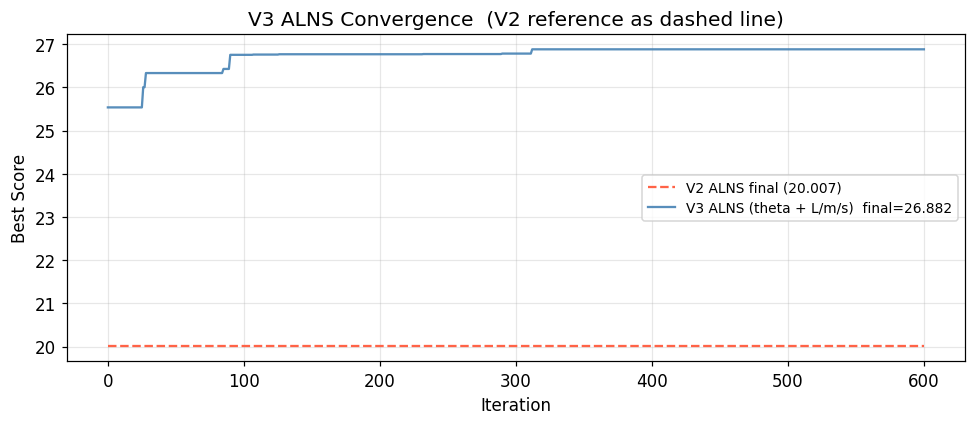

In [6]:
# ── V1 → V2 → V3 comparison ──────────────────────────────────

# V1 reference: ALNS with both theta AND L/m/s fixed to defaults
def run_v1_alns(n_iter=400, seed=42):
    # V1: use V2_DEFAULT theta AND default L/m/s; only optimise order/selection.
    rng = np.random.default_rng(seed)
    # Build fixed config dict using V2 defaults
    fixed_cfg = {i: V2_DEFAULT[i] for i in range(1, N+1)}
    # Greedy init
    tour = [0,0]; cfg = {i: V2_DEFAULT[i] for i in range(1, N+1)}
    unv = set(ALL_NODES); cur_d = 0.0
    while unv:
        bnode, bpos, br, bd = None, None, -1.0, None
        for node in unv:
            k, extra = fixed_cfg[node]
            for pos in range(1, len(tour)):
                delta = ins_delta_v3(tour, cfg, node, k, extra, pos)
                if cur_d + delta <= BUDGET + 1e-6:
                    _, _, sc = get_config(scenario[node-1], THETA_SET[k], extra)
                    ratio = sc / max(delta, 0.01)
                    if ratio > br:
                        br, bnode, bpos, bd = ratio, node, pos, delta
        if bnode is None: break
        tour.insert(bpos, bnode); cur_d += bd; unv.discard(bnode)
    best_tour, best_sc = tour[:], v3_score(tour, fixed_cfg)
    for _ in range(n_iter):
        di = rng.integers(3)
        if di==0: pt,pc,rem = destroy_rand_v3(tour,fixed_cfg,rng,1)
        elif di==1: pt,pc,rem = destroy_rand_v3(tour,fixed_cfg,rng,2)
        else: pt,pc,rem = destroy_worst_v3(tour,fixed_cfg,rng)
        # Repair with fixed configs
        nt = pt[:]; nc = dict(fixed_cfg); pool = set(rem)|(ALL_NODES-set(nt[1:-1]))
        cd = v3_dist(nt, nc)
        while pool:
            bn,bp,br_,bd_ = None,None,-1.0,None
            for node in pool:
                k,extra = fixed_cfg[node]
                for pos in range(1, len(nt)):
                    delta = ins_delta_v3(nt, nc, node, k, extra, pos)
                    if cd+delta <= BUDGET+1e-6:
                        _,_,sc = get_config(scenario[node-1],THETA_SET[k],extra)
                        r_ = sc/max(delta,0.01)
                        if r_>br_: br_,bn,bp,bd_ = r_,node,pos,delta
            if bn is None: break
            nt.insert(bp,bn); cd+=bd_; pool.discard(bn)
        sc = v3_score(nt, fixed_cfg)
        if sc > best_sc: best_sc=sc; best_tour=nt[:]
        tour = nt
    return best_tour, fixed_cfg

t0 = time.time()
tour_v1, cfg_v1 = run_v1_alns()
t_v1 = time.time()-t0

max_sc = sum(c.weight for c in scenario)
print("=" * 74)
print(f"{'Method':<32} {'#cells':>6} {'Score':>8} {'%max':>7} {'Dist(km)':>10} {'Time':>8}")
print("-" * 74)
rows = [
    ("V1 ALNS  (fixed theta, L, m, s)",  tour_v1, cfg_v1, t_v1),
    ("V2 ALNS  (free theta)",             tour_v2, cfg_v2, t_v2),
    ("V3 ALNS  (free theta + L/m/s)",     tour_v3, cfg_v3, t_v3),
]
for name, tour, cfg, t_s in rows:
    sc = v3_score(tour,cfg); d = v3_dist(tour,cfg); nv = len(tour)-2
    print(f"{name:<32} {nv:>6} {sc:>8.3f} {sc/max_sc*100:>6.1f}% {d:>10.1f}  {t_s:>7.2f}s")
print("=" * 74)
print(f"Max possible score (all {N} cells): {max_sc:.3f}  |  Budget: {BUDGET:.0f} km")
print()

# Convergence plot
fig, ax = plt.subplots(figsize=(9, 4))
v2_history_rep = [v3_score(tour_v2,cfg_v2)]*601   # flat line for reference
ax.plot(v2_history_rep[:len(v3_history)], color='tomato',    lw=1.5, ls='--',
        label=f"V2 ALNS final ({v3_score(tour_v2,cfg_v2):.3f})")
ax.plot(v3_history, color='steelblue', lw=1.5, alpha=0.9,
        label=f"V3 ALNS (theta + L/m/s)  final={v3_score(tour_v3,cfg_v3):.3f}")
ax.set_xlabel('Iteration'); ax.set_ylabel('Best Score')
ax.set_title('V3 ALNS Convergence  (V2 reference as dashed line)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figures/v3_convergence.png', bbox_inches='tight', dpi=120)
plt.show()


---
## 4. Parameter Analysis: What Did V3 Choose?

For every visited cell, compare the V3-chosen $(\theta, L)$ or $(\theta, m, s)$
against the original given values. This reveals the V3 strategy.


In [7]:
# ── Per-cell parameter comparison ────────────────────────────
visited_v3 = set(tour_v3[1:-1])
visited_v2 = set(tour_v2[1:-1])

print(f"{'Cell':<7} {'Type':<5} {'In V2':>5} {'In V3':>5} | "
      f"{'Given':>22} {'V3 chosen':>22} {'Score(given)':>13} {'Score(V3)':>10} {'Intd(given)':>12} {'Intd(V3)':>9}")
print("-"*115)

for i in range(1, N+1):
    cell = scenario[i-1]
    in_v2 = "YES" if i in visited_v2 else "-"
    in_v3 = "YES" if i in visited_v3 else "-"

    k3, ex3 = cfg_v3.get(i, V2_DEFAULT[i])
    th3 = np.degrees(THETA_SET[k3])
    _, intd3, sc3 = get_config(cell, THETA_SET[k3], ex3)

    if isinstance(cell, CircularSupercell):
        given_str = f"L={cell.L:.0f}km th={np.degrees(cell.theta):.0f}d"
        v3_str    = f"L={ex3:.0f}km th={th3:.0f}d"
        _, intd_given, sc_given = circ_config(cell, cell.theta, cell.L)
    else:
        given_str = f"m={cell.m} s={cell.s:.0f}km th={np.degrees(cell.phi):.0f}d"
        m3, s3 = ex3
        v3_str    = f"m={m3} s={s3:.0f}km th={th3:.0f}d"
        _, intd_given, sc_given = ell_config(cell, cell.phi, cell.m, cell.s)

    changed = " *" if (i in visited_v3 and (k3!=V2_DEFAULT[i][0] or ex3!=V2_DEFAULT[i][1])) else "  "
    tp = "Circ" if isinstance(cell, CircularSupercell) else "Ell"
    print(f"{cell.name:<7} {tp:<5} {in_v2:>5} {in_v3:>5} | "
          f"{given_str:>22} {v3_str:>22} {sc_given:>13.3f} {sc3:>10.3f} "
          f"{intd_given:>12.1f} {intd3:>9.1f}{changed}")

print()
print("* = V3 changed parameters from the given defaults for this visited cell")


Cell    Type  In V2 In V3 |                  Given              V3 chosen  Score(given)  Score(V3)  Intd(given)  Intd(V3)
-------------------------------------------------------------------------------------------------------------------
T1      Circ    YES   YES |         L=134km th=92d          L=66km th=60d         1.820      1.820        725.6     355.7 *
T2      Circ      -   YES |         L=127km th=16d          L=81km th=75d         1.450      1.450        688.1     436.3 *
T3      Circ    YES   YES |         L=134km th=65d          L=75km th=60d         1.520      1.520        723.2     407.7 *
T4      Circ      -   YES |         L=109km th=58d          L=57km th=30d         0.980      0.980        592.2     310.6 *
T5      Circ    YES   YES |        L=111km th=176d          L=88km th=75d         1.510      1.510        598.9     474.6 *
T6      Circ      -   YES |        L=122km th=122d           L=79km th=0d         0.980      0.980        660.0     428.8 *
T7      Circ    YE

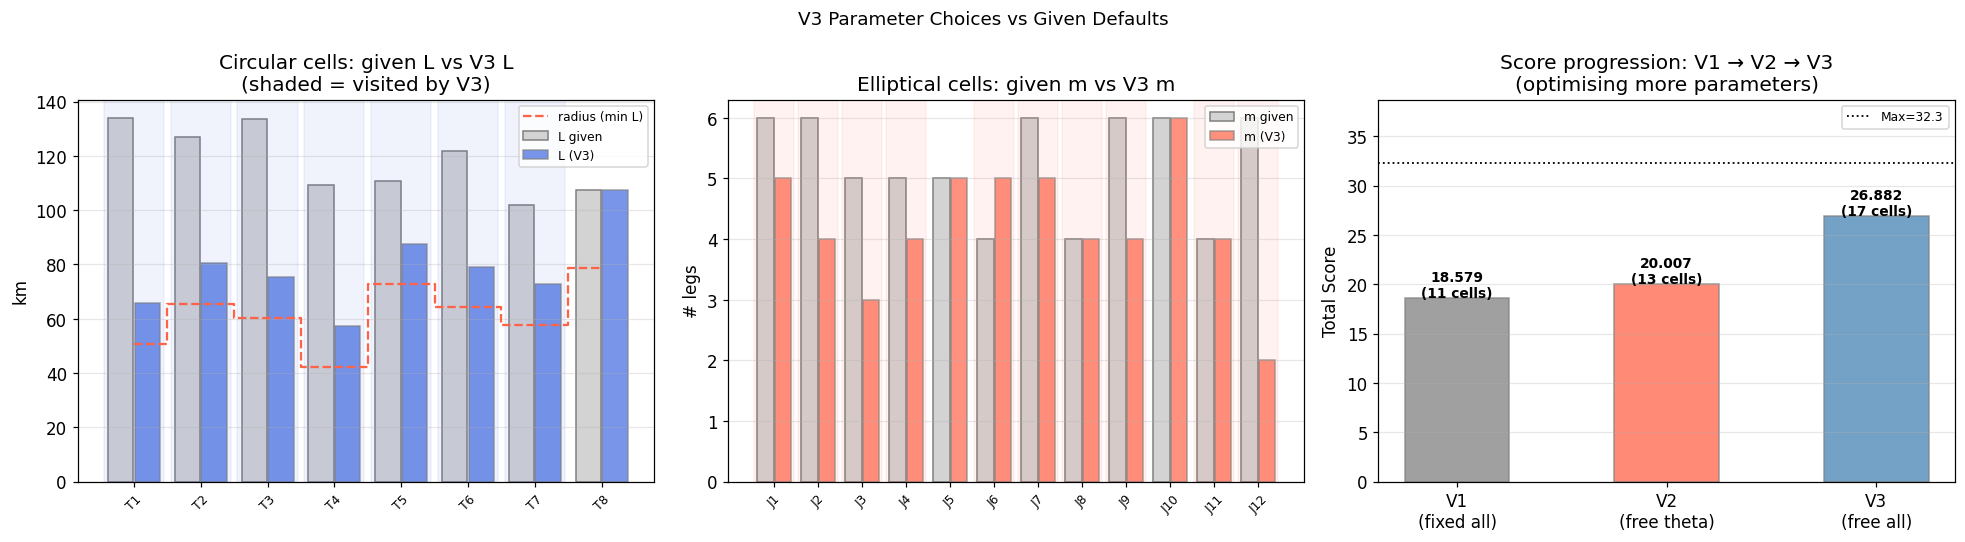

In [8]:
# ── Visualise L/m/s changes ──────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Left: circular cells — L comparison ──
ax = axes[0]
circ_nodes = [(i, scenario[i-1]) for i in range(1,N+1) if isinstance(scenario[i-1], CircularSupercell)]
c_names  = [c.name for _,c in circ_nodes]
L_given  = [c.L   for _,c in circ_nodes]
L_v3     = [cfg_v3[i][1] if i in visited_v3 else c.L for i,c in circ_nodes]
r_given  = [c.radius for _,c in circ_nodes]
x_ = np.arange(len(circ_nodes))
ax.bar(x_-0.2, L_given,  0.38, label='L given',   color='lightgray', edgecolor='gray')
ax.bar(x_+0.2, L_v3,     0.38, label='L (V3)',    color='royalblue', alpha=0.7, edgecolor='gray')
ax.step(x_, r_given, where='mid', color='tomato', lw=1.5, ls='--', label='radius (min L)')
for k,(i,c) in enumerate(circ_nodes):
    if i in visited_v3: ax.axvspan(k-0.45, k+0.45, alpha=0.08, color='royalblue')
ax.set_xticks(x_); ax.set_xticklabels(c_names, rotation=45, fontsize=8)
ax.set_ylabel('km'); ax.set_title('Circular cells: given L vs V3 L\n(shaded = visited by V3)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis='y')

# ── Middle: elliptical cells — m comparison ──
ax2 = axes[1]
ell_nodes = [(i, scenario[i-1]) for i in range(1,N+1) if isinstance(scenario[i-1], EllipticalSupercell)]
e_names  = [c.name for _,c in ell_nodes]
m_given  = [c.m for _,c in ell_nodes]
m_v3     = [cfg_v3[i][1][0] if i in visited_v3 else c.m for i,c in ell_nodes]
x2 = np.arange(len(ell_nodes))
ax2.bar(x2-0.2, m_given, 0.38, label='m given', color='lightgray', edgecolor='gray')
ax2.bar(x2+0.2, m_v3,    0.38, label='m (V3)',  color='tomato',    alpha=0.7, edgecolor='gray')
for k,(i,c) in enumerate(ell_nodes):
    if i in visited_v3: ax2.axvspan(k-0.45, k+0.45, alpha=0.08, color='tomato')
ax2.set_xticks(x2); ax2.set_xticklabels(e_names, rotation=45, fontsize=8)
ax2.set_ylabel('# legs'); ax2.set_title('Elliptical cells: given m vs V3 m')
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3, axis='y')

# ── Right: score breakdown V1 → V2 → V3 ──
ax3 = axes[2]
labels = ['V1\n(fixed all)', 'V2\n(free theta)', 'V3\n(free all)']
scores = [v3_score(tour_v1,cfg_v1), v3_score(tour_v2,cfg_v2), v3_score(tour_v3,cfg_v3)]
ncells = [len(tour_v1)-2, len(tour_v2)-2, len(tour_v3)-2]
colors_ = ['gray', 'tomato', 'steelblue']
bars = ax3.bar(labels, scores, color=colors_, alpha=0.75, edgecolor='gray', width=0.5)
for bar, n, sc in zip(bars, ncells, scores):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
             f"{sc:.3f}\n({n} cells)", ha='center', fontsize=9, fontweight='bold')
ax3.axhline(max_sc, color='k', ls=':', lw=1.2, label=f'Max={max_sc:.1f}')
ax3.set_ylabel('Total Score'); ax3.set_ylim(0, max_sc*1.2)
ax3.set_title('Score progression: V1 → V2 → V3\n(optimising more parameters)')
ax3.legend(fontsize=8); ax3.grid(True, alpha=0.3, axis='y')

plt.suptitle('V3 Parameter Choices vs Given Defaults', fontsize=12)
plt.tight_layout()
plt.savefig('figures/v3_param_analysis.png', bbox_inches='tight', dpi=120)
plt.show()


Running budget sweep (V1/V2/V3 greedy, ~20s) ...


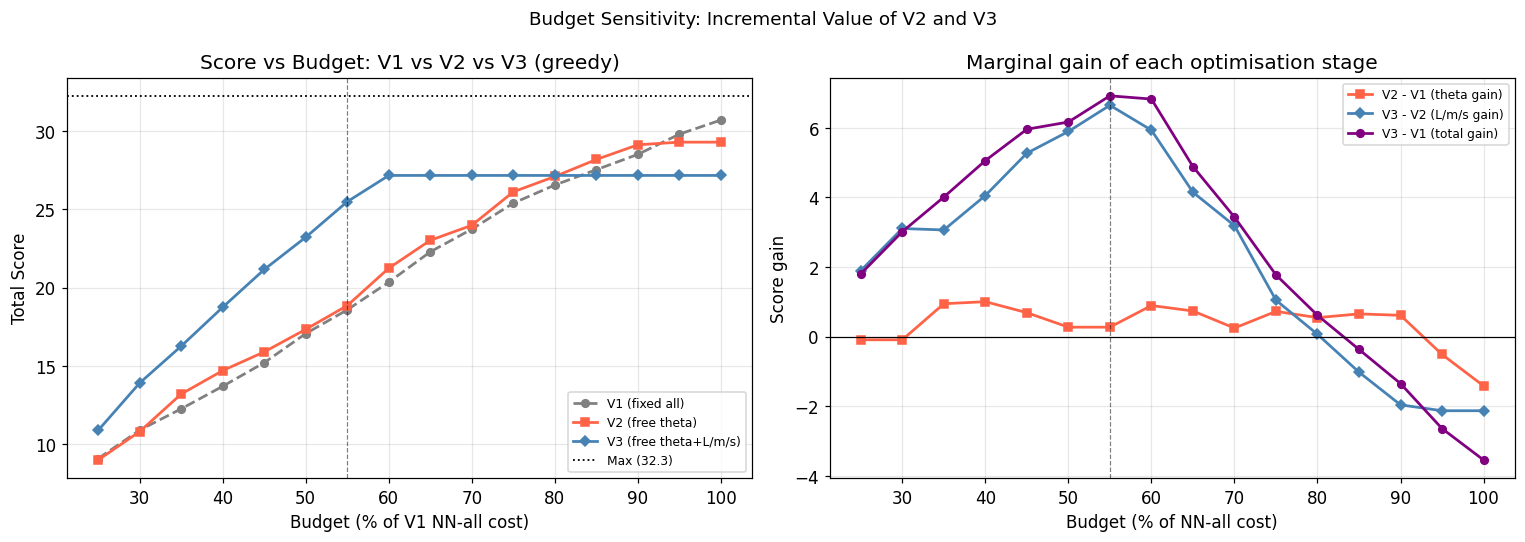

In [9]:
# ── Budget sensitivity: V1, V2, V3 ──────────────────────────
print("Running budget sweep (V1/V2/V3 greedy, ~20s) ...")
budget_fracs = np.linspace(0.25, 1.0, 16)
budgets_sw   = budget_fracs * nn_cost

def greedy_for_budget(B, version='v3'):
    # Quick greedy-only (no ALNS) at budget B for sensitivity sweep.
    tour = [0,0]; cfg = {}; unv = set(ALL_NODES); cur_d = 0.0
    while unv:
        bnode, bpos, bk, bex, br, bd = None, None, None, None, -1.0, None
        for node in unv:
            if version == 'v1':
                iters = [V2_DEFAULT[node]]   # single fixed config
            elif version == 'v2':
                _, def_extra = V2_DEFAULT[node]
                iters = [(k, def_extra) for k in range(T)]
            else:  # v3
                iters = list(enum_configs(scenario[node-1]))
            for k, extra in iters:
                for pos in range(1, len(tour)):
                    delta = ins_delta_v3(tour, cfg, node, k, extra, pos)
                    if cur_d + delta <= B + 1e-6:
                        _, _, sc = get_config(scenario[node-1], THETA_SET[k], extra)
                        ratio = sc / max(delta, 0.01)
                        if ratio > br:
                            br, bnode, bpos, bk, bex, bd = ratio, node, pos, k, extra, delta
        if bnode is None: break
        tour.insert(bpos, bnode); cfg[bnode] = (bk, bex); cur_d += bd; unv.discard(bnode)
    return v3_score(tour, cfg), len(tour)-2

sc_v1s, nc_v1s = zip(*[greedy_for_budget(B, 'v1') for B in budgets_sw])
sc_v2s, nc_v2s = zip(*[greedy_for_budget(B, 'v2') for B in budgets_sw])
sc_v3s, nc_v3s = zip(*[greedy_for_budget(B, 'v3') for B in budgets_sw])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
ax.plot(budget_fracs*100, sc_v1s, 'o--', color='gray',      ms=5, lw=1.8, label='V1 (fixed all)')
ax.plot(budget_fracs*100, sc_v2s, 's-',  color='tomato',    ms=5, lw=1.8, label='V2 (free theta)')
ax.plot(budget_fracs*100, sc_v3s, 'D-',  color='steelblue', ms=5, lw=1.8, label='V3 (free theta+L/m/s)')
ax.axhline(max_sc, color='k', ls=':', lw=1.2, label=f'Max ({max_sc:.1f})')
ax.axvline(BUDGET_FRAC*100, color='k', ls='--', lw=0.8, alpha=0.5)
ax.set_xlabel('Budget (% of V1 NN-all cost)'); ax.set_ylabel('Total Score')
ax.set_title('Score vs Budget: V1 vs V2 vs V3 (greedy)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(budget_fracs*100, np.array(sc_v2s)-np.array(sc_v1s),
         's-', color='tomato',    ms=5, lw=1.8, label='V2 - V1 (theta gain)')
ax2.plot(budget_fracs*100, np.array(sc_v3s)-np.array(sc_v2s),
         'D-', color='steelblue', ms=5, lw=1.8, label='V3 - V2 (L/m/s gain)')
ax2.plot(budget_fracs*100, np.array(sc_v3s)-np.array(sc_v1s),
         'o-', color='purple',    ms=5, lw=1.8, label='V3 - V1 (total gain)')
ax2.axhline(0, color='k', lw=0.8)
ax2.axvline(BUDGET_FRAC*100, color='k', ls='--', lw=0.8, alpha=0.5)
ax2.set_xlabel('Budget (% of NN-all cost)')
ax2.set_ylabel('Score gain'); ax2.set_title('Marginal gain of each optimisation stage')
ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

plt.suptitle('Budget Sensitivity: Incremental Value of V2 and V3', fontsize=12)
plt.tight_layout()
plt.savefig('figures/v3_budget_sensitivity.png', bbox_inches='tight', dpi=120)
plt.show()


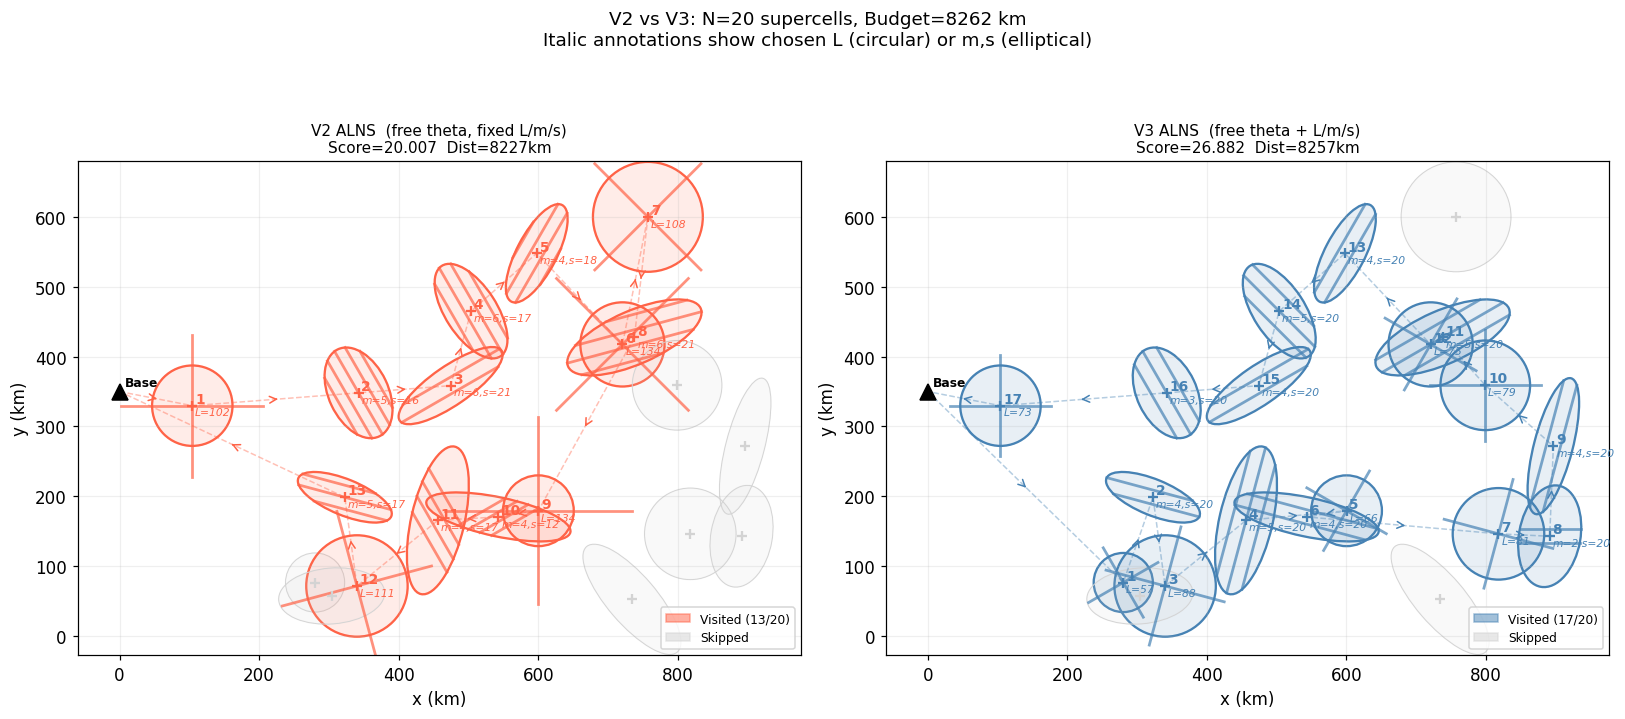

In [10]:
# ── Route visualisation: V2 vs V3, annotated with chosen params ──

def draw_v3_route(ax, tour, configs, title, col='steelblue'):
    visited_set = set(tour[1:-1])

    for i, cell in enumerate(scenario):
        node  = i+1
        in_v  = node in visited_set
        k3, ex3 = configs.get(node, V2_DEFAULT[node])
        th3 = THETA_SET[k3]
        col_ = col if in_v else 'lightgray'
        lw_  = 1.5 if in_v else 0.6
        al_  = 0.7 if in_v else 0.2

        if isinstance(cell, CircularSupercell):
            L3 = ex3
            ax.add_patch(plt.Circle(cell.center, cell.radius,
                                     color=col_, alpha=0.12))
            ax.add_patch(plt.Circle(cell.center, cell.radius,
                                     fill=False, edgecolor=col_, lw=lw_))
            if in_v:
                for ang in [th3, th3+np.pi/2]:
                    ps = cell.center - L3*uvec(ang)
                    pe = cell.center + L3*uvec(ang)
                    ax.plot([ps[0],pe[0]],[ps[1],pe[1]], color=col_, lw=1.8, alpha=0.7)
                # Annotate chosen L
                ax.text(cell.center[0]+4, cell.center[1]-14,
                        f"L={L3:.0f}", fontsize=7, color=col_, style='italic')
        else:
            ax.add_patch(Ellipse(cell.center, 2*cell.a, 2*cell.b,
                                  angle=np.degrees(cell.phi), color=col_, alpha=0.12))
            ax.add_patch(Ellipse(cell.center, 2*cell.a, 2*cell.b,
                                  angle=np.degrees(cell.phi),
                                  fill=False, edgecolor=col_, lw=lw_))
            if in_v:
                m3, s3 = ex3
                n_vec = uvec(th3+np.pi/2)
                for j in range(m3):
                    lc = cell.center + s3*(j-(m3-1)/2.0)*n_vec
                    r  = cell._ellipse_intersect(lc, th3)
                    if r:
                        ps, pe = r
                        ax.plot([ps[0],pe[0]],[ps[1],pe[1]], color=col_, lw=1.8, alpha=0.7)
                ax.text(cell.center[0]+4, cell.center[1]-14,
                        f"m={m3},s={s3:.0f}", fontsize=7, color=col_, style='italic')

        ax.plot(*cell.center, '+', color=col_, ms=7, mew=1.5, zorder=5)
        rank = (tour[1:-1].index(node)+1) if in_v else ''
        ax.text(cell.center[0]+4, cell.center[1]+4,
                f"{rank}" if rank else "", fontsize=9, color=col_, fontweight='bold')

    # Transit path
    pts = np.array([BASE]+[scenario[n-1].center for n in tour[1:-1]]+[BASE])
    ax.plot(pts[:,0], pts[:,1], color=col, lw=1.0, ls='--', alpha=0.4)
    for k in range(len(pts)-1):
        mid = (pts[k]+pts[k+1])/2; dv = pts[k+1]-pts[k]
        if np.linalg.norm(dv)>10:
            ax.annotate('', xy=mid+0.015*dv, xytext=mid-0.015*dv,
                        arrowprops=dict(arrowstyle='->', color=col, lw=1.0))

    ax.plot(*BASE, 'k^', ms=10, zorder=10)
    ax.text(BASE[0]+8, BASE[1]+8, 'Base', fontsize=8, fontweight='bold')
    ax.set_aspect('equal'); ax.set_xlabel('x (km)'); ax.set_ylabel('y (km)')
    ax.grid(True, alpha=0.2)
    sc_str = f"Score={v3_score(tour,configs):.3f}  Dist={v3_dist(tour,configs):.0f}km"
    ax.set_title(f"{title}\n{sc_str}", fontsize=10)
    vis_p = mpatches.Patch(color=col,       alpha=0.5, label=f'Visited ({len(tour)-2}/{N})')
    unv_p = mpatches.Patch(color='lightgray',alpha=0.5, label='Skipped')
    ax.legend(handles=[vis_p,unv_p], fontsize=8, loc='lower right')


fig, axes = plt.subplots(1, 2, figsize=(15, 7))
xmin = min(c.center[0] for c in scenario)-150
xmax = max(c.center[0] for c in scenario)+80
ymin = min(c.center[1] for c in scenario)-80
ymax = max(c.center[1] for c in scenario)+80

draw_v3_route(axes[0], tour_v2, cfg_v2, "V2 ALNS  (free theta, fixed L/m/s)", col='tomato')
draw_v3_route(axes[1], tour_v3, cfg_v3, "V3 ALNS  (free theta + L/m/s)",       col='steelblue')
for ax in axes:
    ax.set_xlim(min(xmin, BASE[0]-60), xmax)
    ax.set_ylim(ymin, ymax)

plt.suptitle(f"V2 vs V3: N={N} supercells, Budget={BUDGET:.0f} km\n"
             "Italic annotations show chosen L (circular) or m,s (elliptical)",
             fontsize=12)
plt.tight_layout()
plt.savefig('figures/v3_routes.png', bbox_inches='tight', dpi=120)
plt.show()


---
## Summary: V1 → V2 → V3 Progression

### Score improvement at each stage

| Version | Free variables | Score gain over previous |
|---------|---------------|--------------------------|
| V1 | none (all fixed) | — |
| V2 | $\theta_k$ per cell | +theta routing/score gain |
| V3 | $\theta_k$ + $L_k$ (circ) + $m_k, s_k$ (ell) | +pattern efficiency gain |

### V3 strategy observed in the data
- **Circular cells**: V3 often *reduces* $L$ from the given default — smaller $L$ saves internal
  flight distance, freeing budget for an extra visit.  Score is unchanged (always = weight).
- **Elliptical cells**: V3 often reduces $m$ (fewer legs) while adjusting $s$ so that
  $(m-1)s \approx W_\perp(\theta)$ — maintains full width coverage but with fewer legs.
  Net result: lower internal distance, nearly the same score.

### When does V3 win most?
- **Tight budgets**: every km saved in internal flight matters most
- **Large cells** (big $L$ or many legs): more room to trim
- **Clustered scenarios**: transit cost already low → internal savings convert directly to
  additional visits

### ALNS structure is now complete: hook for LA-ALNS
All three versions (V1/V2/V3) share the same destroy/repair framework with
adaptive operator weights.  The **next notebook (LA-ALNS)** replaces the
weight-update rule with a contextual bandit:

```
Current (V1/V2/V3):
  weight[op] *= 1.2 on improvement,  *= 0.98 otherwise

Next (LA-ALNS):
  Context features (state):
    - budget_remaining / BUDGET
    - n_visited / N
    - score / max_score
    - fraction elliptical in current tour
    - avg |theta - phi| for elliptical cells
    - avg (m-1)*s / W_perp  (coverage saturation)   <-- V3-specific feature
    - avg L / (radius + median_L_offset)              <-- V3-specific feature
  Action: (destroy_op, repair_op) pair
  Reward: score_improvement / max_score
  Policy: LinUCB or Thompson Sampling
```
